In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ptick 

In [2]:
nGrover = 200
nShot = 100
alpha = 0.05
epsilon = 0.001

In [3]:
pTrue = 0.2505
thetaTrue = np.arcsin(np.sqrt(pTrue))
k = 2 * nGrover + 1
r = int(k * thetaTrue / (0.5 * np.pi))
pEstim_l = np.sin((0.5 * np.pi * r) / k) ** 2
pEstim_u = np.sin((0.5 * np.pi * (r + 1)) / k) ** 2
pEstims = np.linspace(pEstim_l, pEstim_u, num=1000, endpoint=False)

kmax = np.pi / 4 / epsilon
alphaRound = 2 * alpha / 3 * k / kmax

pus = []
pls = []
ciWidths = []
for pEstim in pEstims:

    # pEstim to p
    theta = np.arcsin(np.sqrt(pEstim))
    prob1 = np.sin(k * theta) ** 2

    p1Width = np.sqrt(0.5 / nShot * np.log(2 / alphaRound))
    p1Max = min(prob1 + p1Width, 1)
    p1Min = max(prob1 - p1Width, 0)

    if r % 2 == 0:
        gammaMin = np.arcsin(np.sqrt(p1Min))
        gammaMax = np.arcsin(np.sqrt(p1Max))
    else:
        gammaMin = 0.5 * np.pi - np.arcsin(np.sqrt(p1Max))
        gammaMax = 0.5 * np.pi - np.arcsin(np.sqrt(p1Min))

    theta_u = (r * 0.5 * np.pi + gammaMax) / k
    theta_l = (r * 0.5 * np.pi + gammaMin) / k

    pu = np.sin(theta_u) ** 2
    pl = np.sin(theta_l) ** 2
    ciWidth = max(pu - pEstim, pEstim - pl)

    pus.append(pu)
    pls.append(pl)
    ciWidths.append(ciWidth)


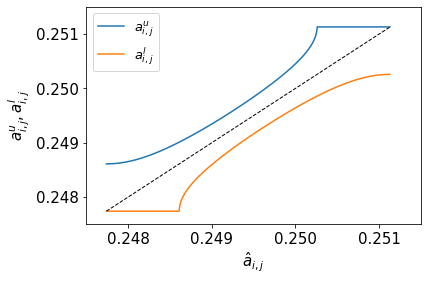

In [6]:
plt.rcParams["font.size"] = 15

ax = plt.gca()
plt.plot(pEstims, pus, label="$a^u_{i,j}$")
plt.plot(pEstims, pls, label="$a^l_{i,j}$")
plt.plot(pEstims, pEstims, linestyle="dashed", color='k', lw=1)
plt.legend(fontsize=13)
ax.set_xlim((0.2475, 0.2515))
ax.set_ylim((0.2475, 0.2515))
ax.set_xlabel("$\hat{a}_{i,j}$")
ax.set_ylabel("$a^u_{i,j},a^l_{i,j}$")
plt.show()

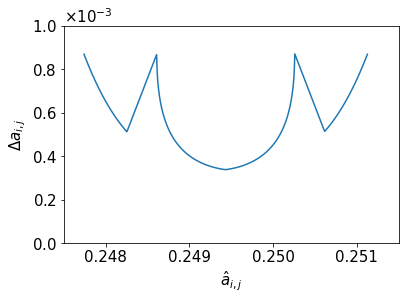

In [13]:
plt.rcParams["font.size"] = 15

ax = plt.gca()
plt.plot(pEstims, ciWidths)
ax.set_xlim((0.2475, 0.2515))
ax.set_ylim((0, 0.001))
ax.set_xlabel("$\hat{a}_{i,j}$")
ax.set_ylabel("$\Delta a_{i,j}$")
ax.yaxis.set_major_formatter(ptick.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="y", scilimits=(-3,-3))
plt.show()